# HBL Stock Direction Prediction — BiLSTM + Attention + Sentiment
## Classification Model (v1) — Research Paper Version

**Task:** Predict whether HBL's 5-day cumulative return will be **UP (1)** or **DOWN (0)**

**Why classification instead of regression?**
- Daily/weekly stock returns are near-random walk → regression R² is almost always negative in literature
- Direction prediction is the standard in academic ML-finance papers
- Sentiment features are naturally directional signals (positive news → up, negative → down)
- Metrics (Accuracy, F1, AUC-ROC) are clean, interpretable, and defensible in peer review

**Paper contribution this notebook demonstrates:**
1. BiLSTM + Attention baseline (price features only)
2. BiLSTM + Attention + Sentiment (full model)
3. Ablation study: does sentiment actually help? (direct answer to research question)

---
**Dataset:** HBL (Habib Bank Limited) — PSX  
**Period:** Jan 2016 – Aug 2025  
**Sentiment source:** Dawn News (daily, quarterly, annual)

## Section 1 — Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve
)
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Bidirectional, LSTM, Dense, Dropout,
    LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Configuration ─────────────────────────────────────────────────────────────
SEQUENCE_LENGTH = 30      # Days of history per sample
FORWARD_DAYS    = 5       # Predict direction of 5-day cumulative return
LSTM_UNITS_1    = 128
LSTM_UNITS_2    = 64
ATTN_HEADS      = 4
ATTN_KEY_DIM    = 32
DROPOUT_RATE    = 0.3
LEARNING_RATE   = 1e-3
BATCH_SIZE      = 32
MAX_EPOCHS      = 100
TRAIN_RATIO     = 0.70
VAL_RATIO       = 0.15

# ── Paths — UPDATE THESE ──────────────────────────────────────────────────────
DATA_PATH        = r'C:\Users\Admin\Desktop\Fyp Working\Classification Model\hbl_merged_dataset_clean.csv'
MODEL_FULL_PATH  = r'C:\Users\Admin\Desktop\Fyp Working\Classification Model\bilstm_clf_full.keras'
MODEL_PRICE_PATH = r'C:\Users\Admin\Desktop\Fyp Working\Classification Model\bilstm_clf_priceonly.keras'
SCALER_PATH      = r'C:\Users\Admin\Desktop\Fyp Working\Classification Model\scalers.pkl'

print('✅ Libraries loaded')
print(f'   TensorFlow : {tf.__version__}')
print(f'   Task       : {FORWARD_DAYS}-day direction classification (UP / DOWN)')
print(f'   Sequence   : {SEQUENCE_LENGTH} days lookback')

C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framewo

✅ Libraries loaded
   TensorFlow : 2.20.0
   Task       : 5-day direction classification (UP / DOWN)
   Sequence   : 30 days lookback


C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## Section 2 — Load Data & Engineer Features

Two feature sets are built here:
- **`PRICE_FEATURES`** — technical indicators only (price + volume)
- **`FULL_FEATURES`** — price + all sentiment features

Both will be trained separately for the ablation study.

In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)
print(f'Loaded {len(df)} rows  |  {df["date"].min().date()} → {df["date"].max().date()}')

# ═══════════════════════════════════════════════════════════
# TECHNICAL FEATURES
# ═══════════════════════════════════════════════════════════

# Returns
df['ret_1']  = df['log_return']
df['ret_5']  = df['log_return'].rolling(5).sum()
df['ret_10'] = df['log_return'].rolling(10).sum()
df['ret_20'] = df['log_return'].rolling(20).sum()

# Volatility
df['vol_5']  = df['log_return'].rolling(5).std()
df['vol_10'] = df['log_return'].rolling(10).std()
df['vol_20'] = df['log_return'].rolling(20).std()

# Moving average momentum
df['sma_10'] = df['Close'].rolling(10).mean()
df['sma_20'] = df['Close'].rolling(20).mean()
df['sma_50'] = df['Close'].rolling(50).mean()
df['mom_10'] = (df['Close'] - df['sma_10']) / df['sma_10']
df['mom_20'] = (df['Close'] - df['sma_20']) / df['sma_20']
df['mom_50'] = (df['Close'] - df['sma_50']) / df['sma_50']

# ATR-14 (normalised volatility)
hl   = df['High'] - df['Low']
hc   = (df['High'] - df['Close'].shift(1)).abs()
lc   = (df['Low']  - df['Close'].shift(1)).abs()
tr   = pd.concat([hl, hc, lc], axis=1).max(axis=1)
df['atr_14'] = tr.rolling(14).mean() / df['Close']

# Bollinger Bands
bb_std = df['Close'].rolling(20).std()
bb_upper = df['sma_20'] + 2 * bb_std
bb_lower = df['sma_20'] - 2 * bb_std
df['bb_width'] = (bb_upper - bb_lower) / df['sma_20']
df['bb_pos']   = (df['Close'] - bb_lower) / (bb_upper - bb_lower + 1e-9)

# RSI-14 (normalised 0-1)
delta = df['Close'].diff()
gain  = delta.clip(lower=0).rolling(14).mean()
loss  = (-delta.clip(upper=0)).rolling(14).mean()
df['rsi_14'] = 1 - 1 / (1 + gain / (loss + 1e-9))

# MACD (signal line crossover)
ema12 = df['Close'].ewm(span=12).mean()
ema26 = df['Close'].ewm(span=26).mean()
df['macd']        = (ema12 - ema26) / df['Close']
df['macd_signal'] = df['macd'].ewm(span=9).mean()
df['macd_hist']   = df['macd'] - df['macd_signal']

# Volume features
df['vol_ratio']   = df['Volume'] / (df['Volume'].rolling(20).mean() + 1e-9)
df['vol_ret_corr']= df['log_return'].rolling(10).corr(df['Volume'].pct_change())

# Price range (intraday)
df['intraday_range'] = (df['High'] - df['Low']) / df['Close']

# ═══════════════════════════════════════════════════════════
# SENTIMENT FEATURES (engineered)
# ═══════════════════════════════════════════════════════════

# Sentiment surprise: unexpected shift from recent average
df['sent_mean_10']  = df['daily_sentiment'].rolling(10).mean()
df['sent_surprise'] = df['daily_sentiment'] - df['sent_mean_10']

# Sentiment momentum: is sentiment improving or worsening?
df['sent_ma3']      = df['daily_sentiment'].rolling(3).mean()
df['sent_ma7']      = df['daily_sentiment'].rolling(7).mean()
df['sent_momentum'] = df['sent_ma3'] - df['sent_ma7']

# Sentiment volatility: how unstable is news sentiment?
df['sent_vol']      = df['daily_sentiment'].rolling(10).std()

# Positive/negative ratio (from raw counts)
total_articles = df['daily_pos'] + df['daily_neg'] + df['daily_neu'] + 1e-9
df['pos_ratio'] = df['daily_pos'] / total_articles
df['neg_ratio'] = df['daily_neg'] / total_articles
df['sent_polarity'] = df['pos_ratio'] - df['neg_ratio']  # Net sentiment

# News volume surprise
df['news_vol_ratio'] = df['daily_news_count'] / (df['daily_news_count'].rolling(20).mean() + 1e-9)

# Quarterly and annual sentiment (fundamental backdrop)
# Already in df: quarterly_sentiment, annual_sentiment, daily_sentiment

# ═══════════════════════════════════════════════════════════
# TARGET: 5-day forward direction
# ═══════════════════════════════════════════════════════════
df['return_5d_fwd'] = sum(df['log_return'].shift(-i) for i in range(1, FORWARD_DAYS + 1))
df['target']        = (df['return_5d_fwd'] > 0).astype(int)  # 1=UP, 0=DOWN

# ═══════════════════════════════════════════════════════════
# FEATURE SETS
# ═══════════════════════════════════════════════════════════
PRICE_FEATURES = [
    'ret_1', 'ret_5', 'ret_10', 'ret_20',
    'vol_5', 'vol_10', 'vol_20', 'atr_14',
    'mom_10', 'mom_20', 'mom_50',
    'rsi_14', 'bb_width', 'bb_pos',
    'macd', 'macd_signal', 'macd_hist',
    'vol_ratio', 'vol_ret_corr', 'intraday_range',
]

SENTIMENT_FEATURES = [
    'daily_sentiment',
    'sent_surprise',
    'sent_momentum',
    'sent_vol',
    'sent_polarity',
    'pos_ratio',
    'neg_ratio',
    'news_vol_ratio',
    'quarterly_sentiment',
    'annual_sentiment',
]

FULL_FEATURES = PRICE_FEATURES + SENTIMENT_FEATURES

# Drop NaN rows
all_cols = FULL_FEATURES + ['target', 'return_5d_fwd', 'date', 'Close', 'log_return']
df_clean = df[all_cols].dropna().reset_index(drop=True)

print(f'\nClean rows     : {len(df_clean)}')
print(f'Price features : {len(PRICE_FEATURES)}')
print(f'Sent features  : {len(SENTIMENT_FEATURES)}')
print(f'Full features  : {len(FULL_FEATURES)}')
print(f'\nClass balance:')
vc = df_clean['target'].value_counts()
print(f'  UP   (1): {vc[1]:4d} ({vc[1]/len(df_clean):.1%})')
print(f'  DOWN (0): {vc[0]:4d} ({vc[0]/len(df_clean):.1%})')

Loaded 2503 rows  |  2015-12-31 → 2025-08-28

Clean rows     : 1666
Price features : 20
Sent features  : 10
Full features  : 30

Class balance:
  UP   (1):  793 (47.6%)
  DOWN (0):  873 (52.4%)


## Section 3 — Train / Val / Test Split

In [3]:
n = len(df_clean)
train_end = int(n * TRAIN_RATIO)
val_end   = int(n * (TRAIN_RATIO + VAL_RATIO))

train_df = df_clean.iloc[:train_end].reset_index(drop=True)
val_df   = df_clean.iloc[train_end:val_end].reset_index(drop=True)
test_df  = df_clean.iloc[val_end:].reset_index(drop=True)

print(f'Train : {len(train_df):4d} rows  {train_df["date"].min().date()} → {train_df["date"].max().date()}')
print(f'Val   : {len(val_df):4d} rows  {val_df["date"].min().date()} → {val_df["date"].max().date()}')
print(f'Test  : {len(test_df):4d} rows  {test_df["date"].min().date()} → {test_df["date"].max().date()}')

# Class balance per split
for name, d in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    up = d['target'].mean()
    print(f'  {name} UP: {up:.1%}  DOWN: {1-up:.1%}')

# ── RobustScaler on features ──────────────────────────────────────────────────
# Classification: we scale features but NOT the target (it's already 0/1)
import pickle, os

scaler_full  = RobustScaler()
scaler_price = RobustScaler()

# Fit ONLY on train — prevents data leakage
Xf_train = scaler_full.fit_transform(train_df[FULL_FEATURES])
Xf_val   = scaler_full.transform(val_df[FULL_FEATURES])
Xf_test  = scaler_full.transform(test_df[FULL_FEATURES])

Xp_train = scaler_price.fit_transform(train_df[PRICE_FEATURES])
Xp_val   = scaler_price.transform(val_df[PRICE_FEATURES])
Xp_test  = scaler_price.transform(test_df[PRICE_FEATURES])

y_train = train_df['target'].values
y_val   = val_df['target'].values
y_test  = test_df['target'].values

os.makedirs(os.path.dirname(SCALER_PATH), exist_ok=True)
with open(SCALER_PATH, 'wb') as f:
    pickle.dump({'full': scaler_full, 'price': scaler_price,
                 'price_features': PRICE_FEATURES,
                 'full_features': FULL_FEATURES}, f)
print('\n✅ Scalers saved')

Train : 1166 rows  2016-03-09 → 2022-11-08
Val   :  250 rows  2022-11-09 → 2024-04-24
Test  :  250 rows  2024-04-25 → 2025-08-21
  Train UP: 46.3%  DOWN: 53.7%
  Val UP: 49.2%  DOWN: 50.8%
  Test UP: 52.0%  DOWN: 48.0%

✅ Scalers saved


## Section 4 — Build Sequences

In [4]:
def build_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i - seq_len:i])
        ys.append(y[i])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

# Full model sequences
Xf_tr, yf_tr = build_sequences(Xf_train, y_train, SEQUENCE_LENGTH)
Xf_va, yf_va = build_sequences(Xf_val,   y_val,   SEQUENCE_LENGTH)
Xf_te, yf_te = build_sequences(Xf_test,  y_test,  SEQUENCE_LENGTH)

# Price-only sequences (for ablation study)
Xp_tr, yp_tr = build_sequences(Xp_train, y_train, SEQUENCE_LENGTH)
Xp_va, yp_va = build_sequences(Xp_val,   y_val,   SEQUENCE_LENGTH)
Xp_te, yp_te = build_sequences(Xp_test,  y_test,  SEQUENCE_LENGTH)

print(f'Full model — Train: {Xf_tr.shape}  Val: {Xf_va.shape}  Test: {Xf_te.shape}')
print(f'Price only — Train: {Xp_tr.shape}  Val: {Xp_va.shape}  Test: {Xp_te.shape}')

# ── Class weights to handle 53/47 imbalance ───────────────────────────────────
# This tells the model to penalise mistakes on the minority class more heavily
classes = np.array([0, 1])
cw = compute_class_weight('balanced', classes=classes, y=yf_tr)
class_weight_dict = {0: cw[0], 1: cw[1]}
print(f'\nClass weights: DOWN(0)={cw[0]:.3f}  UP(1)={cw[1]:.3f}')

Full model — Train: (1136, 30, 30)  Val: (220, 30, 30)  Test: (220, 30, 30)
Price only — Train: (1136, 30, 20)  Val: (220, 30, 20)  Test: (220, 30, 20)

Class weights: DOWN(0)=0.927  UP(1)=1.086


## Section 5 — Model Architecture

### Key difference from regression version

| Layer | Regression | Classification |
|-------|-----------|----------------|
| Output activation | `linear` | **`sigmoid`** (outputs probability 0→1) |
| Loss | directional MSE | **`binary_crossentropy`** |
| Metrics | RMSE, R², Pearson r | **Accuracy, F1, AUC-ROC** |
| Interpretation | "stock will move by X%" | **"probability of going UP = X%"** |

In [5]:
def build_model(seq_len, n_features, name='BiLSTM_Clf'):
    """
    BiLSTM + Multi-Head Attention for binary classification.
    Output: sigmoid probability of UP direction.
    """
    inputs = Input(shape=(seq_len, n_features), name='input')

    # BiLSTM block 1
    x = Bidirectional(
        LSTM(LSTM_UNITS_1, return_sequences=True,
             dropout=DROPOUT_RATE, recurrent_dropout=0.1),
        name='bilstm_1'
    )(inputs)
    x = LayerNormalization()(x)
    x = Dropout(DROPOUT_RATE)(x)

    # BiLSTM block 2
    x = Bidirectional(
        LSTM(LSTM_UNITS_2, return_sequences=True,
             dropout=DROPOUT_RATE, recurrent_dropout=0.1),
        name='bilstm_2'
    )(x)
    x = LayerNormalization()(x)
    x = Dropout(DROPOUT_RATE)(x)

    # Multi-Head Attention
    # Learns which of the 30 days in the window matter most
    attn = MultiHeadAttention(
        num_heads=ATTN_HEADS, key_dim=ATTN_KEY_DIM,
        dropout=DROPOUT_RATE, name='attention'
    )(x, x)
    x = LayerNormalization()(x + attn)  # Residual connection

    # Pool over time axis
    x = GlobalAveragePooling1D()(x)

    # Dense head
    x = Dense(64, activation='relu')(x)
    x = Dropout(DROPOUT_RATE / 2)(x)
    x = Dense(32, activation='relu')(x)

    # OUTPUT: sigmoid → probability of UP (1)
    outputs = Dense(1, activation='sigmoid', name='output')(x)

    model = Model(inputs, outputs, name=name)
    model.compile(
        optimizer = Adam(learning_rate=LEARNING_RATE),
        loss      = 'binary_crossentropy',  # Standard for binary classification
        metrics   = ['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model


# Build both models
model_full  = build_model(SEQUENCE_LENGTH, len(FULL_FEATURES),  name='Full_BiLSTM_Clf')
model_price = build_model(SEQUENCE_LENGTH, len(PRICE_FEATURES), name='Price_BiLSTM_Clf')

print('═══ Full Model (Price + Sentiment) ═══')
model_full.summary()
print(f'\n  Parameters: {model_full.count_params():,}')

═══ Full Model (Price + Sentiment) ═══


Model: "Full_BiLSTM_Clf"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)            │ (None, 30, 30)            │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bilstm_1 (Bidirectional)      │ (None, 30, 256)           │         162,816 │ input[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization           │ (None, 30, 256)           │             512 │ bilstm_1[0][0]             │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 30, 256)           │               0 │ layer_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bilstm_2 (Bidirectional)      │ (None, 30, 128)           │         164,352 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization_1         │ (None, 30, 128)           │             256 │ bilstm_2[0][0]             │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 30, 128)           │               0 │ layer_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ attention                     │ (None, 30, 128)           │          66,048 │ dropout_1[0][0],           │
│ (MultiHeadAttention)          │                           │                 │ dropout_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 30, 128)           │               0 │ dropout_1[0][0],           │
│                               │                           │                 │ attention[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization_2         │ (None, 30, 128)           │             256 │ add[0][0]                  │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling1d      │ (None, 128)               │               0 │ layer_normalization_2[0][… │
│ (GlobalAveragePooling1D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 64)                │           8,256 │ global_average_pooling1d[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_3 (Dropout)           │ (None, 64)                │               0 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 32)                │           2,080 │ dropout_3[0][0]            │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 404,609 (1.54 MB)

 Trainable params: 404,609 (1.54 MB)

 Non-trainable params: 0 (0.00 B)


  Parameters: 404,609


## Section 6 — Train Full Model (Price + Sentiment)

In [6]:
def get_callbacks(save_path):
    return [
        EarlyStopping(monitor='val_auc', patience=15,
                      restore_best_weights=True, mode='max', verbose=1),
        ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=7,
                          min_lr=1e-6, mode='max', verbose=1),
        ModelCheckpoint(save_path, monitor='val_auc',
                        save_best_only=True, mode='max', verbose=0)
    ]

print('🚀 Training FULL model (price + sentiment)...')
hist_full = model_full.fit(
    Xf_tr, yf_tr,
    validation_data = (Xf_va, yf_va),
    epochs          = MAX_EPOCHS,
    batch_size      = BATCH_SIZE,
    class_weight    = class_weight_dict,
    callbacks       = get_callbacks(MODEL_FULL_PATH),
    verbose         = 1
)
print('✅ Full model training complete')

🚀 Training FULL model (price + sentiment)...
Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 17s 136ms/step - accuracy: 0.5299 - auc: 0.5491 - loss: 0.6982 - val_accuracy: 0.4136 - val_auc: 0.3911 - val_loss: 0.7605 - learning_rate: 0.0010
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - accuracy: 0.5599 - auc: 0.5989 - loss: 0.6791 - val_accuracy: 0.4273 - val_auc: 0.4291 - val_loss: 0.7872 - learning_rate: 0.0010
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - accuracy: 0.6144 - auc: 0.6481 - loss: 0.6584 - val_accuracy: 0.4409 - val_auc: 0.4952 - val_loss: 0.7440 - learning_rate: 0.0010
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - accuracy: 0.6162 - auc: 0.6696 - loss: 0.6429 - val_accuracy: 0.4273 - val_auc: 0.4167 - val_loss: 0.8286 - learning_rate: 0.0010
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - accuracy: 0.6382 - auc: 0.6922 - loss: 0.6308 - val_accuracy: 0.4636 - val_auc: 0.4911 - val_loss: 0.8216 - learning_rate: 0.0010
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━

## Section 7 — Train Price-Only Model (Ablation Baseline)

In [7]:
print('🚀 Training PRICE-ONLY model (ablation baseline)...')
hist_price = model_price.fit(
    Xp_tr, yp_tr,
    validation_data = (Xp_va, yp_va),
    epochs          = MAX_EPOCHS,
    batch_size      = BATCH_SIZE,
    class_weight    = class_weight_dict,
    callbacks       = get_callbacks(MODEL_PRICE_PATH),
    verbose         = 1
)
print('✅ Price-only model training complete')

🚀 Training PRICE-ONLY model (ablation baseline)...
Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 16s 132ms/step - accuracy: 0.5202 - auc: 0.5405 - loss: 0.7063 - val_accuracy: 0.4455 - val_auc: 0.4657 - val_loss: 0.7510 - learning_rate: 0.0010
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - accuracy: 0.5467 - auc: 0.5759 - loss: 0.6863 - val_accuracy: 0.4864 - val_auc: 0.4404 - val_loss: 0.7928 - learning_rate: 0.0010
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - accuracy: 0.5766 - auc: 0.6112 - loss: 0.6786 - val_accuracy: 0.4455 - val_auc: 0.4268 - val_loss: 0.8656 - learning_rate: 0.0010
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - accuracy: 0.6136 - auc: 0.6518 - loss: 0.6562 - val_accuracy: 0.4636 - val_auc: 0.4438 - val_loss: 0.9431 - learning_rate: 0.0010
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - accuracy: 0.6408 - auc: 0.6957 - loss: 0.6325 - val_accuracy: 0.4455 - val_auc: 0.4306 - val_loss: 0.9243 - learning_rate: 0.0010
Epoch 6/100
36/36 ━━━━━━━━━

## Section 7b — Explicit Model Save

ModelCheckpoint already saved the best weights during training.
This cell saves them again explicitly with clear, permanent names
so you always know exactly which file is which.

In [8]:
import os

# ── Save directory ────────────────────────────────────────────────────────────
SAVE_DIR = r'C:\Users\Admin\Desktop\Fyp Working\models\Classification'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Model 1: Full model (Price + Sentiment) ───────────────────────────────────
# This is your MAIN model — BiLSTM + Attention trained on all 30 features
full_save_path = os.path.join(SAVE_DIR, 'HBL_BiLSTM_Attention_Price_Sentiment.keras')
model_full.save(full_save_path)
size_full = os.path.getsize(full_save_path) / 1024
print(f'✅ Model 1 saved: HBL_BiLSTM_Attention_Price_Sentiment.keras')
print(f'   Path : {full_save_path}')
print(f'   Size : {size_full:.1f} KB')
print(f'   Input: (batch, {SEQUENCE_LENGTH}, {len(FULL_FEATURES)})  →  Output: sigmoid probability')

print()

# ── Model 2: Price-only model (Ablation baseline) ─────────────────────────────
# This is your ABLATION BASELINE — same architecture, no sentiment features
price_save_path = os.path.join(SAVE_DIR, 'HBL_BiLSTM_Attention_PriceOnly_Baseline.keras')
model_price.save(price_save_path)
size_price = os.path.getsize(price_save_path) / 1024
print(f'✅ Model 2 saved: HBL_BiLSTM_Attention_PriceOnly_Baseline.keras')
print(f'   Path : {price_save_path}')
print(f'   Size : {size_price:.1f} KB')
print(f'   Input: (batch, {SEQUENCE_LENGTH}, {len(PRICE_FEATURES)})  →  Output: sigmoid probability')

print()
print('── What each model is for ───────────────────────────────────────')
print(f'  HBL_BiLSTM_Attention_Price_Sentiment.keras')
print(f'    → Your MAIN contribution model (cite this in paper)')
print(f'    → Features: {len(PRICE_FEATURES)} technical + {len(SENTIMENT_FEATURES)} sentiment = {len(FULL_FEATURES)} total')
print()
print(f'  HBL_BiLSTM_Attention_PriceOnly_Baseline.keras')
print(f'    → Ablation baseline (proves sentiment adds value)')
print(f'    → Features: {len(PRICE_FEATURES)} technical only')
print('─────────────────────────────────────────────────────────────────')

# ── Verify both load correctly ────────────────────────────────────────────────
print('\nVerifying models load correctly...')
import tensorflow as tf
test_load_full  = tf.keras.models.load_model(full_save_path)
test_load_price = tf.keras.models.load_model(price_save_path)

# Quick sanity check — run one prediction through each
dummy_full  = np.zeros((1, SEQUENCE_LENGTH, len(FULL_FEATURES)),  dtype=np.float32)
dummy_price = np.zeros((1, SEQUENCE_LENGTH, len(PRICE_FEATURES)), dtype=np.float32)
out_full    = test_load_full.predict(dummy_full,  verbose=0)[0][0]
out_price   = test_load_price.predict(dummy_price, verbose=0)[0][0]

print(f'✅ HBL_BiLSTM_Attention_Price_Sentiment  — loads OK  (test output: {out_full:.4f})')
print(f'✅ HBL_BiLSTM_Attention_PriceOnly_Baseline — loads OK  (test output: {out_price:.4f})')
print('\nBoth models verified and ready.')

✅ Model 1 saved: HBL_BiLSTM_Attention_Price_Sentiment.keras
   Path : C:\Users\Admin\Desktop\Fyp Working\models\Classification\HBL_BiLSTM_Attention_Price_Sentiment.keras
   Size : 4854.5 KB
   Input: (batch, 30, 30)  →  Output: sigmoid probability

✅ Model 2 saved: HBL_BiLSTM_Attention_PriceOnly_Baseline.keras
   Path : C:\Users\Admin\Desktop\Fyp Working\models\Classification\HBL_BiLSTM_Attention_PriceOnly_Baseline.keras
   Size : 4734.5 KB
   Input: (batch, 30, 20)  →  Output: sigmoid probability

── What each model is for ───────────────────────────────────────
  HBL_BiLSTM_Attention_Price_Sentiment.keras
    → Your MAIN contribution model (cite this in paper)
    → Features: 20 technical + 10 sentiment = 30 total

  HBL_BiLSTM_Attention_PriceOnly_Baseline.keras
    → Ablation baseline (proves sentiment adds value)
    → Features: 20 technical only
─────────────────────────────────────────────────────────────────

Verifying models load correctly...
✅ HBL_BiLSTM_Attention_Price_Sentim

## Section 8 — Training Curves

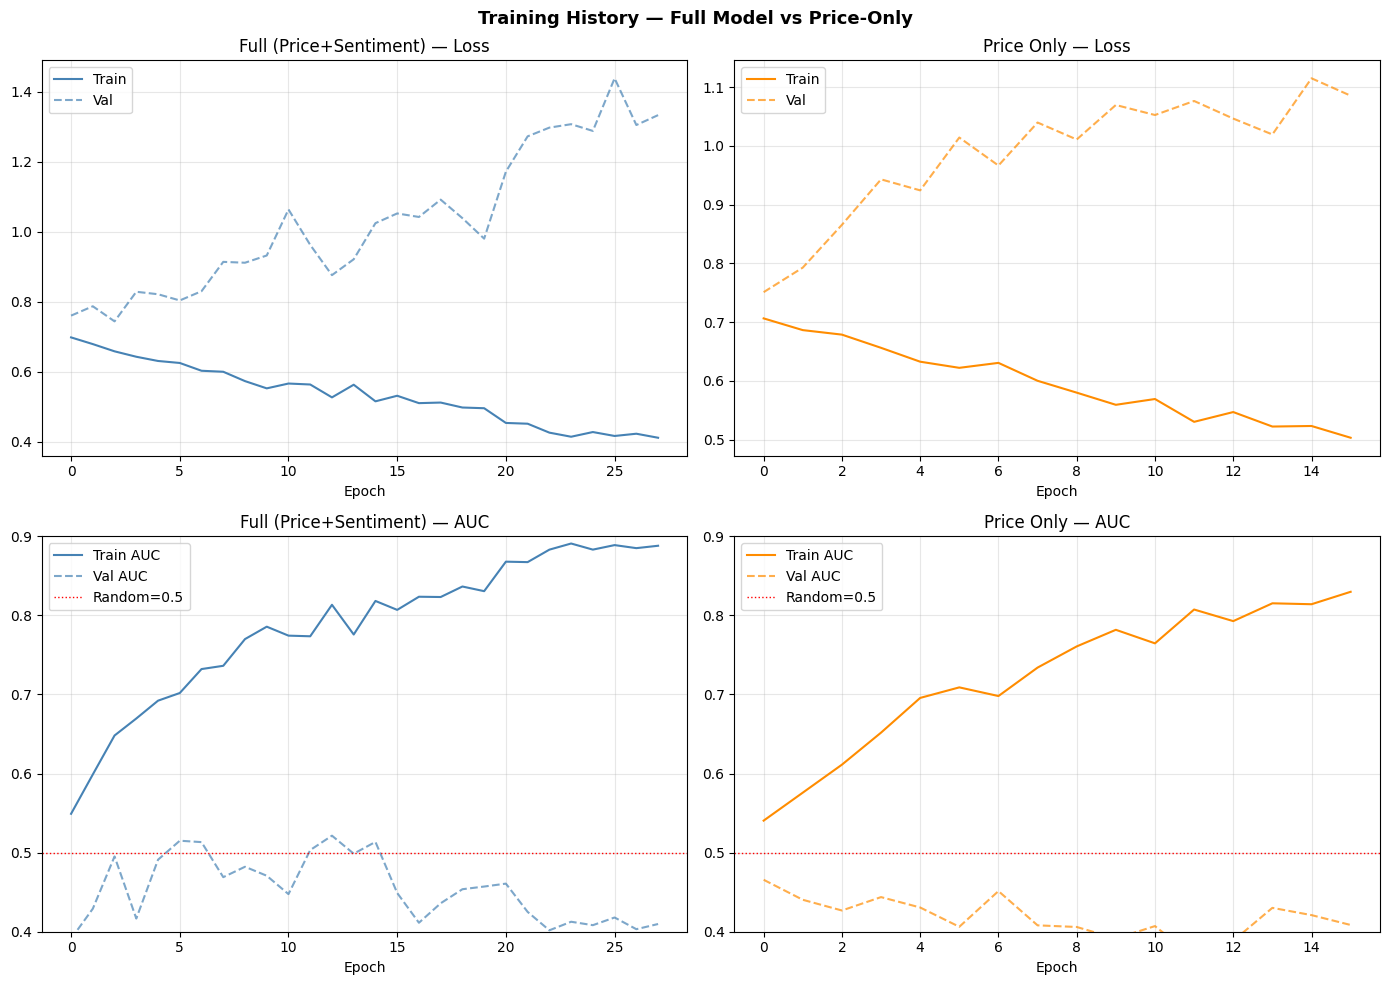

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Training History — Full Model vs Price-Only', fontsize=13, fontweight='bold')

for col, (hist, label, color) in enumerate([
    (hist_full,  'Full (Price+Sentiment)', 'steelblue'),
    (hist_price, 'Price Only',            'darkorange')
]):
    # Loss
    axes[0, col].plot(hist.history['loss'],     label='Train', color=color)
    axes[0, col].plot(hist.history['val_loss'], label='Val',   color=color, linestyle='--', alpha=0.7)
    axes[0, col].set_title(f'{label} — Loss')
    axes[0, col].legend()
    axes[0, col].grid(True, alpha=0.3)
    axes[0, col].set_xlabel('Epoch')

    # AUC
    axes[1, col].plot(hist.history['auc'],     label='Train AUC', color=color)
    axes[1, col].plot(hist.history['val_auc'], label='Val AUC',   color=color, linestyle='--', alpha=0.7)
    axes[1, col].axhline(0.5, color='red', linewidth=1, linestyle=':', label='Random=0.5')
    axes[1, col].set_title(f'{label} — AUC')
    axes[1, col].set_ylim(0.4, 0.9)
    axes[1, col].legend()
    axes[1, col].grid(True, alpha=0.3)
    axes[1, col].set_xlabel('Epoch')

plt.tight_layout()
plt.savefig('training_curves_clf.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 9 — Full Evaluation on Test Set

In [10]:
def evaluate_model(model, X_test, y_test, label='Model', threshold=0.5):
    """
    Full classification evaluation.
    Returns dict of all metrics for the paper's results table.
    """
    proba = model.predict(X_test, verbose=0).flatten()  # P(UP)
    preds = (proba >= threshold).astype(int)

    acc   = accuracy_score(y_test, preds)
    f1    = f1_score(y_test, preds, average='weighted')
    f1_up = f1_score(y_test, preds, pos_label=1)
    f1_dn = f1_score(y_test, preds, pos_label=0)
    auc   = roc_auc_score(y_test, proba)

    print(f'\n═══ {label} — Test Set Results ═══')
    print(f'  Accuracy          : {acc:.4f}  ({acc:.1%})')
    print(f'  Weighted F1       : {f1:.4f}')
    print(f'  F1 (UP class)     : {f1_up:.4f}')
    print(f'  F1 (DOWN class)   : {f1_dn:.4f}')
    print(f'  AUC-ROC           : {auc:.4f}')
    print(f'\n{classification_report(y_test, preds, target_names=["DOWN","UP"])}')

    return {
        'label': label, 'proba': proba, 'preds': preds,
        'accuracy': acc, 'f1': f1, 'f1_up': f1_up,
        'f1_down': f1_dn, 'auc': auc
    }

res_full  = evaluate_model(model_full,  Xf_te, yf_te, label='Full (Price + Sentiment)')
res_price = evaluate_model(model_price, Xp_te, yp_te, label='Price Only (Baseline)')


═══ Full (Price + Sentiment) — Test Set Results ═══
  Accuracy          : 0.4227  (42.3%)
  Weighted F1       : 0.4186
  F1 (UP class)     : 0.4774
  F1 (DOWN class)   : 0.3553
  AUC-ROC           : 0.4048

              precision    recall  f1-score   support

        DOWN       0.38      0.33      0.36       106
          UP       0.45      0.51      0.48       114

    accuracy                           0.42       220
   macro avg       0.42      0.42      0.42       220
weighted avg       0.42      0.42      0.42       220


═══ Price Only (Baseline) — Test Set Results ═══
  Accuracy          : 0.4045  (40.5%)
  Weighted F1       : 0.3910
  F1 (UP class)     : 0.4903
  F1 (DOWN class)   : 0.2842
  AUC-ROC           : 0.3623

              precision    recall  f1-score   support

        DOWN       0.34      0.25      0.28       106
          UP       0.44      0.55      0.49       114

    accuracy                           0.40       220
   macro avg       0.39      0.40      0.3

## Section 10 — ROC Curve Comparison

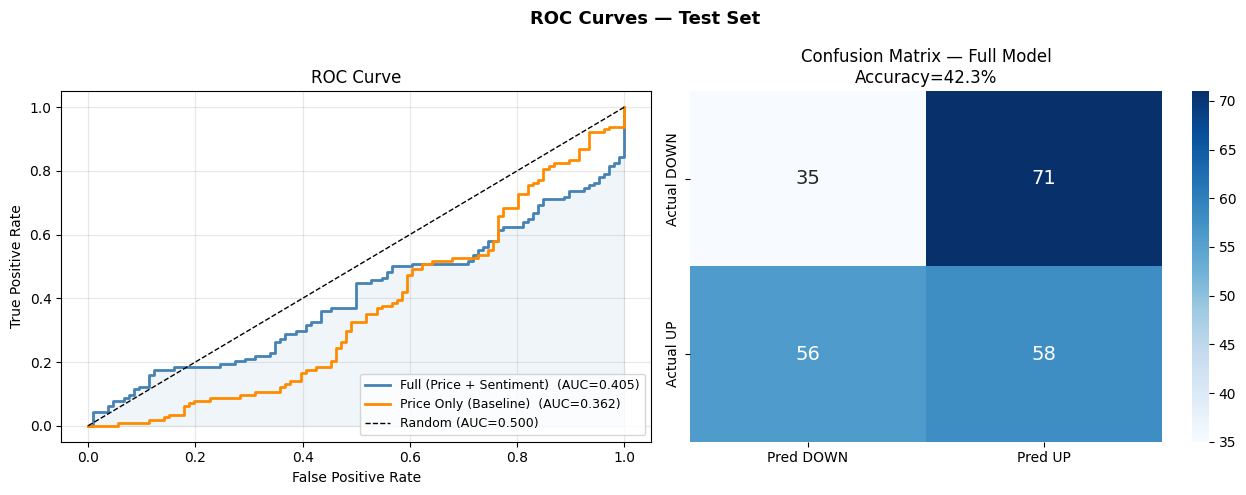

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('ROC Curves — Test Set', fontsize=13, fontweight='bold')

# ROC comparison
ax = axes[0]
for res, color in [(res_full, 'steelblue'), (res_price, 'darkorange')]:
    fpr, tpr, _ = roc_curve(yf_te, res['proba'])
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{res['label']}  (AUC={res['auc']:.3f})")
ax.plot([0,1],[0,1],'k--', linewidth=1, label='Random (AUC=0.500)')
ax.fill_between(*roc_curve(yf_te, res_full['proba'])[:2],
                alpha=0.08, color='steelblue')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)

# Confusion matrix — Full model
ax2 = axes[1]
cm = confusion_matrix(yf_te, res_full['preds'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['Pred DOWN', 'Pred UP'],
            yticklabels=['Actual DOWN', 'Actual UP'],
            annot_kws={'size': 14})
ax2.set_title(f'Confusion Matrix — Full Model\nAccuracy={res_full["accuracy"]:.1%}')

plt.tight_layout()
plt.savefig('roc_confusion_clf.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 11 — Threshold Optimisation

The default threshold is 0.5 (predict UP if P(UP) > 50%). But the optimal
threshold that maximises F1 may be different. We find it on the **validation set**.

Optimal threshold (max val F1): 0.66


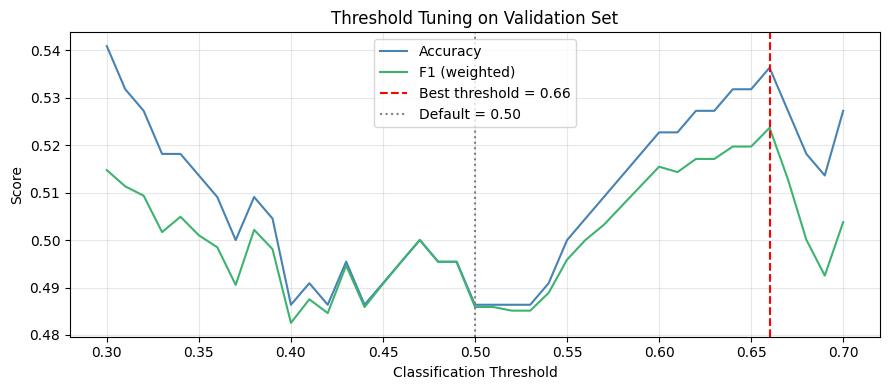


With optimal threshold:

═══ Full Model (optimal threshold) — Test Set Results ═══
  Accuracy          : 0.4500  (45.0%)
  Weighted F1       : 0.4285
  F1 (UP class)     : 0.3315
  F1 (DOWN class)   : 0.5328
  AUC-ROC           : 0.4048

              precision    recall  f1-score   support

        DOWN       0.45      0.65      0.53       106
          UP       0.45      0.26      0.33       114

    accuracy                           0.45       220
   macro avg       0.45      0.46      0.43       220
weighted avg       0.45      0.45      0.43       220



In [12]:
# Get probabilities on validation set
proba_va = model_full.predict(Xf_va, verbose=0).flatten()

thresholds = np.arange(0.30, 0.71, 0.01)
val_accs, val_f1s, val_aucs = [], [], []

for t in thresholds:
    p = (proba_va >= t).astype(int)
    val_accs.append(accuracy_score(yf_va, p))
    val_f1s.append(f1_score(yf_va, p, average='weighted', zero_division=0))

best_thresh = thresholds[np.argmax(val_f1s)]
print(f'Optimal threshold (max val F1): {best_thresh:.2f}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, val_accs, label='Accuracy', color='steelblue')
ax.plot(thresholds, val_f1s,  label='F1 (weighted)', color='mediumseagreen')
ax.axvline(best_thresh, color='red', linestyle='--',
           label=f'Best threshold = {best_thresh:.2f}')
ax.axvline(0.5, color='gray', linestyle=':', label='Default = 0.50')
ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold Tuning on Validation Set')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('threshold_tuning_clf.png', dpi=150, bbox_inches='tight')
plt.show()

# Re-evaluate with optimal threshold
print('\nWith optimal threshold:')
res_full_opt = evaluate_model(model_full, Xf_te, yf_te,
                               label='Full Model (optimal threshold)',
                               threshold=best_thresh)

## Section 12 — Ablation Study

**This is the core contribution of your paper.**

The ablation study directly answers: *"Does adding sentiment analysis improve prediction?"*

If `Full > Price-Only`, sentiment is contributing. The difference is the measurable
value of your Dawn News sentiment data.

In [13]:
# ── Random baseline ───────────────────────────────────────────────────────────
# Always predict the majority class (DOWN)
majority_class = int(np.round(1 - yf_te.mean()))  # 0 if DOWN is majority
random_preds   = np.full_like(yf_te, majority_class)
random_acc     = accuracy_score(yf_te, random_preds)
random_f1      = f1_score(yf_te, random_preds, average='weighted', zero_division=0)
random_auc     = 0.5  # By definition

# ── Ablation table ─────────────────────────────────────────────────────────────
ablation = pd.DataFrame([
    {
        'Model': 'Majority Class Baseline',
        'Features': 'None',
        'Accuracy': random_acc,
        'F1 (weighted)': random_f1,
        'F1 (UP)': 0.0,
        'F1 (DOWN)': f1_score(yf_te, random_preds, pos_label=0, zero_division=0),
        'AUC-ROC': random_auc,
    },
    {
        'Model': 'BiLSTM + Attention (Price Only)',
        'Features': f'{len(PRICE_FEATURES)} technical',
        'Accuracy': res_price['accuracy'],
        'F1 (weighted)': res_price['f1'],
        'F1 (UP)': res_price['f1_up'],
        'F1 (DOWN)': res_price['f1_down'],
        'AUC-ROC': res_price['auc'],
    },
    {
        'Model': 'BiLSTM + Attention (Price + Sentiment)',
        'Features': f'{len(FULL_FEATURES)} total',
        'Accuracy': res_full_opt['accuracy'],
        'F1 (weighted)': res_full_opt['f1'],
        'F1 (UP)': res_full_opt['f1_up'],
        'F1 (DOWN)': res_full_opt['f1_down'],
        'AUC-ROC': res_full_opt['auc'],
    },
])

print('\n═══════════════════════════════════════════════════════════════')
print('              ABLATION STUDY — RESULTS TABLE')
print('        (Copy this directly into your research paper)')
print('═══════════════════════════════════════════════════════════════')
print(ablation.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# Sentiment uplift
acc_uplift = res_full_opt['accuracy'] - res_price['accuracy']
auc_uplift = res_full_opt['auc']      - res_price['auc']
print(f'\nSentiment uplift → Accuracy: +{acc_uplift:.4f} ({acc_uplift:.2%})')
print(f'Sentiment uplift → AUC-ROC:  +{auc_uplift:.4f}')
print('\n(If positive: sentiment IS contributing to predictive power)')


═══════════════════════════════════════════════════════════════
              ABLATION STUDY — RESULTS TABLE
        (Copy this directly into your research paper)
═══════════════════════════════════════════════════════════════
                                 Model     Features  Accuracy  F1 (weighted)  F1 (UP)  F1 (DOWN)  AUC-ROC
               Majority Class Baseline         None    0.4818         0.3133   0.0000     0.6503   0.5000
       BiLSTM + Attention (Price Only) 20 technical    0.4045         0.3910   0.4903     0.2842   0.3623
BiLSTM + Attention (Price + Sentiment)     30 total    0.4500         0.4285   0.3315     0.5328   0.4048

Sentiment uplift → Accuracy: +0.0455 (4.55%)
Sentiment uplift → AUC-ROC:  +0.0425

(If positive: sentiment IS contributing to predictive power)


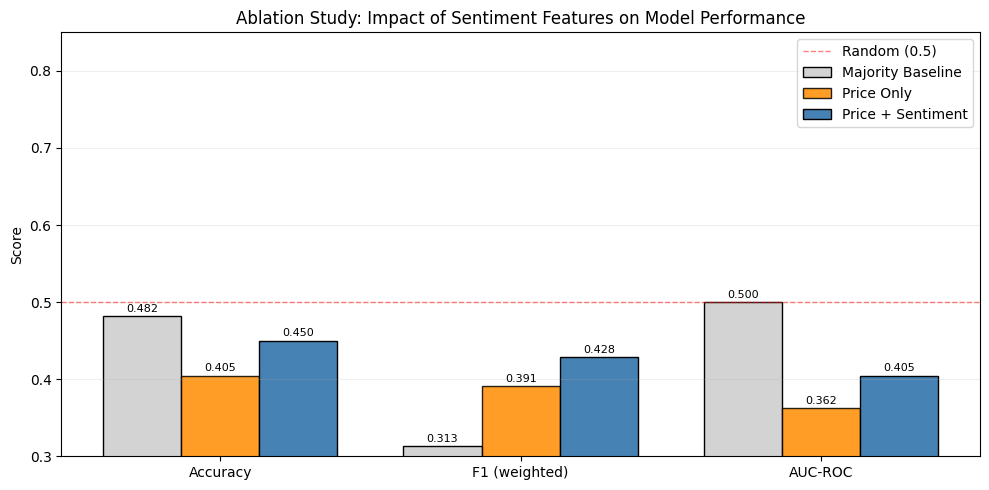

In [14]:
# ── Visual ablation comparison ─────────────────────────────────────────────────
metrics   = ['Accuracy', 'F1 (weighted)', 'AUC-ROC']
baseline  = [ablation.iloc[0][m] for m in metrics]
price_val = [ablation.iloc[1][m] for m in metrics]
full_val  = [ablation.iloc[2][m] for m in metrics]

x = np.arange(len(metrics))
w = 0.26

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w, baseline,  w, label='Majority Baseline', color='lightgray',  edgecolor='black')
b2 = ax.bar(x,     price_val, w, label='Price Only',        color='darkorange', edgecolor='black', alpha=0.85)
b3 = ax.bar(x + w, full_val,  w, label='Price + Sentiment', color='steelblue',  edgecolor='black')

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.003,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.3, 0.85)
ax.axhline(0.5, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Random (0.5)')
ax.set_ylabel('Score')
ax.set_title('Ablation Study: Impact of Sentiment Features on Model Performance')
ax.legend()
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.savefig('ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 13 — Feature Importance (Permutation)

Computing feature importance (takes ~2 min)...


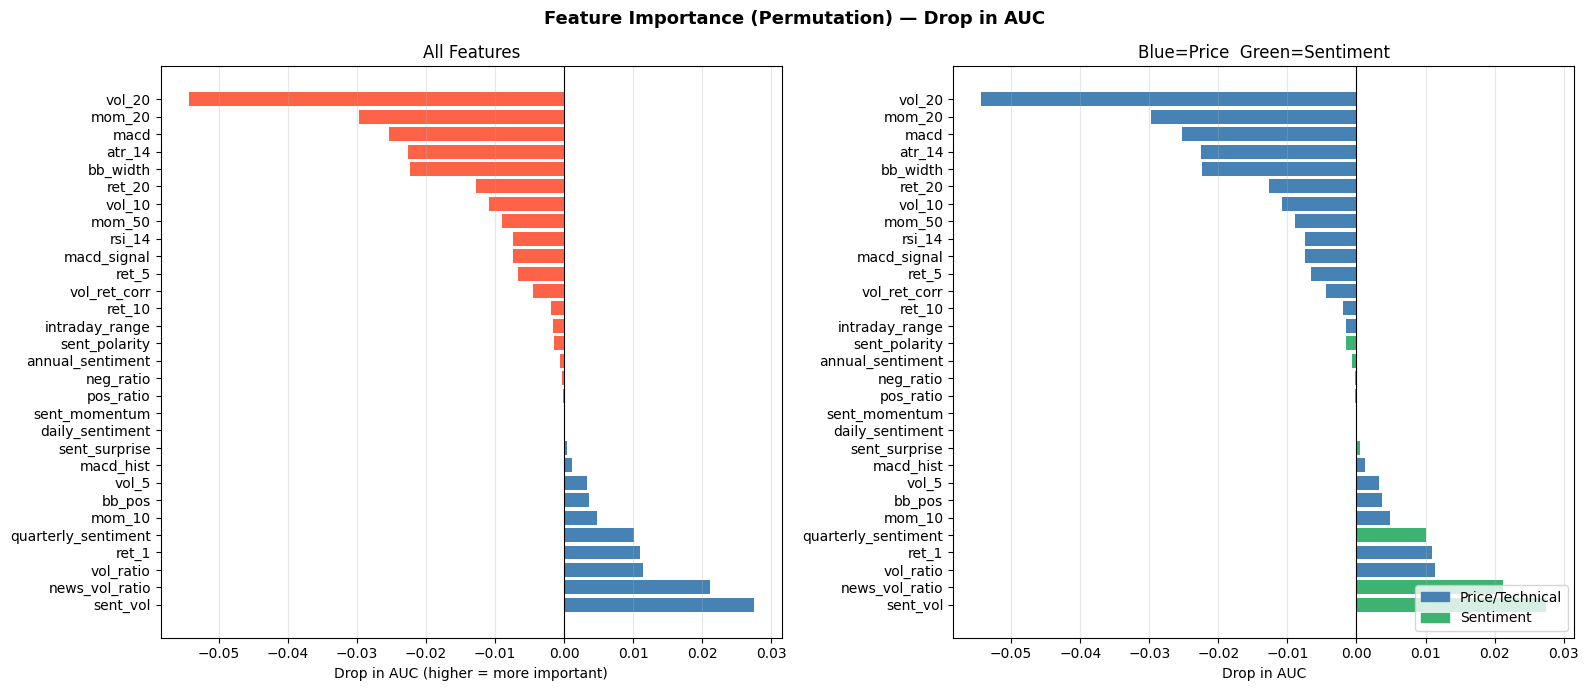


Top 10 most important features:
            feature  importance
           sent_vol    0.027474
     news_vol_ratio    0.021157
          vol_ratio    0.011420
              ret_1    0.011006
quarterly_sentiment    0.010068
             mom_10    0.004827
             bb_pos    0.003641
              vol_5    0.003310
          macd_hist    0.001186
      sent_surprise    0.000497

Sentiment features importance summary:
            feature  importance
           sent_vol    0.027474
     news_vol_ratio    0.021157
quarterly_sentiment    0.010068
      sent_surprise    0.000497
    daily_sentiment    0.000138
      sent_momentum   -0.000055
          pos_ratio   -0.000193
          neg_ratio   -0.000276
   annual_sentiment   -0.000634
      sent_polarity   -0.001517


In [15]:
def permutation_importance_clf(model, X, y, feature_names, n_repeats=3):
    """Permutation importance for classification: metric = AUC."""
    base_proba = model.predict(X, verbose=0).flatten()
    base_auc   = roc_auc_score(y, base_proba)

    importances = []
    for feat_idx in range(X.shape[2]):
        drops = []
        for _ in range(n_repeats):
            X_perm = X.copy()
            perm = np.random.permutation(X_perm.shape[0])
            X_perm[:, :, feat_idx] = X_perm[perm, :, feat_idx]
            perm_proba = model.predict(X_perm, verbose=0).flatten()
            perm_auc   = roc_auc_score(y, perm_proba)
            drops.append(base_auc - perm_auc)  # Drop in AUC = importance
        importances.append(np.mean(drops))

    return pd.DataFrame({'feature': feature_names,
                         'importance': importances}).sort_values('importance', ascending=False)

print('Computing feature importance (takes ~2 min)...')
imp_df = permutation_importance_clf(model_full, Xf_te, yf_te, FULL_FEATURES, n_repeats=3)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Feature Importance (Permutation) — Drop in AUC', fontsize=13, fontweight='bold')

# All features
colors = ['steelblue' if v >= 0 else 'tomato' for v in imp_df['importance']]
axes[0].barh(imp_df['feature'], imp_df['importance'], color=colors)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Drop in AUC (higher = more important)')
axes[0].set_title('All Features')
axes[0].grid(True, alpha=0.3, axis='x')

# Colour code by type
sent_feats  = set(SENTIMENT_FEATURES)
colors2 = ['mediumseagreen' if f in sent_feats else 'steelblue'
           for f in imp_df['feature']]
axes[1].barh(imp_df['feature'], imp_df['importance'], color=colors2)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Drop in AUC')
axes[1].set_title('Blue=Price  Green=Sentiment')
axes[1].grid(True, alpha=0.3, axis='x')

# Legend
from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(color='steelblue',    label='Price/Technical'),
    Patch(color='mediumseagreen',label='Sentiment'),
], loc='lower right')

plt.tight_layout()
plt.savefig('feature_importance_clf.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 most important features:')
print(imp_df.head(10).to_string(index=False))
print('\nSentiment features importance summary:')
print(imp_df[imp_df['feature'].isin(sent_feats)].to_string(index=False))

## Section 14 — Prediction Probability Over Time

This is a clean visualisation showing what the model is outputting day-by-day.
Values near 1.0 = model is confident about UP. Near 0.0 = confident about DOWN.

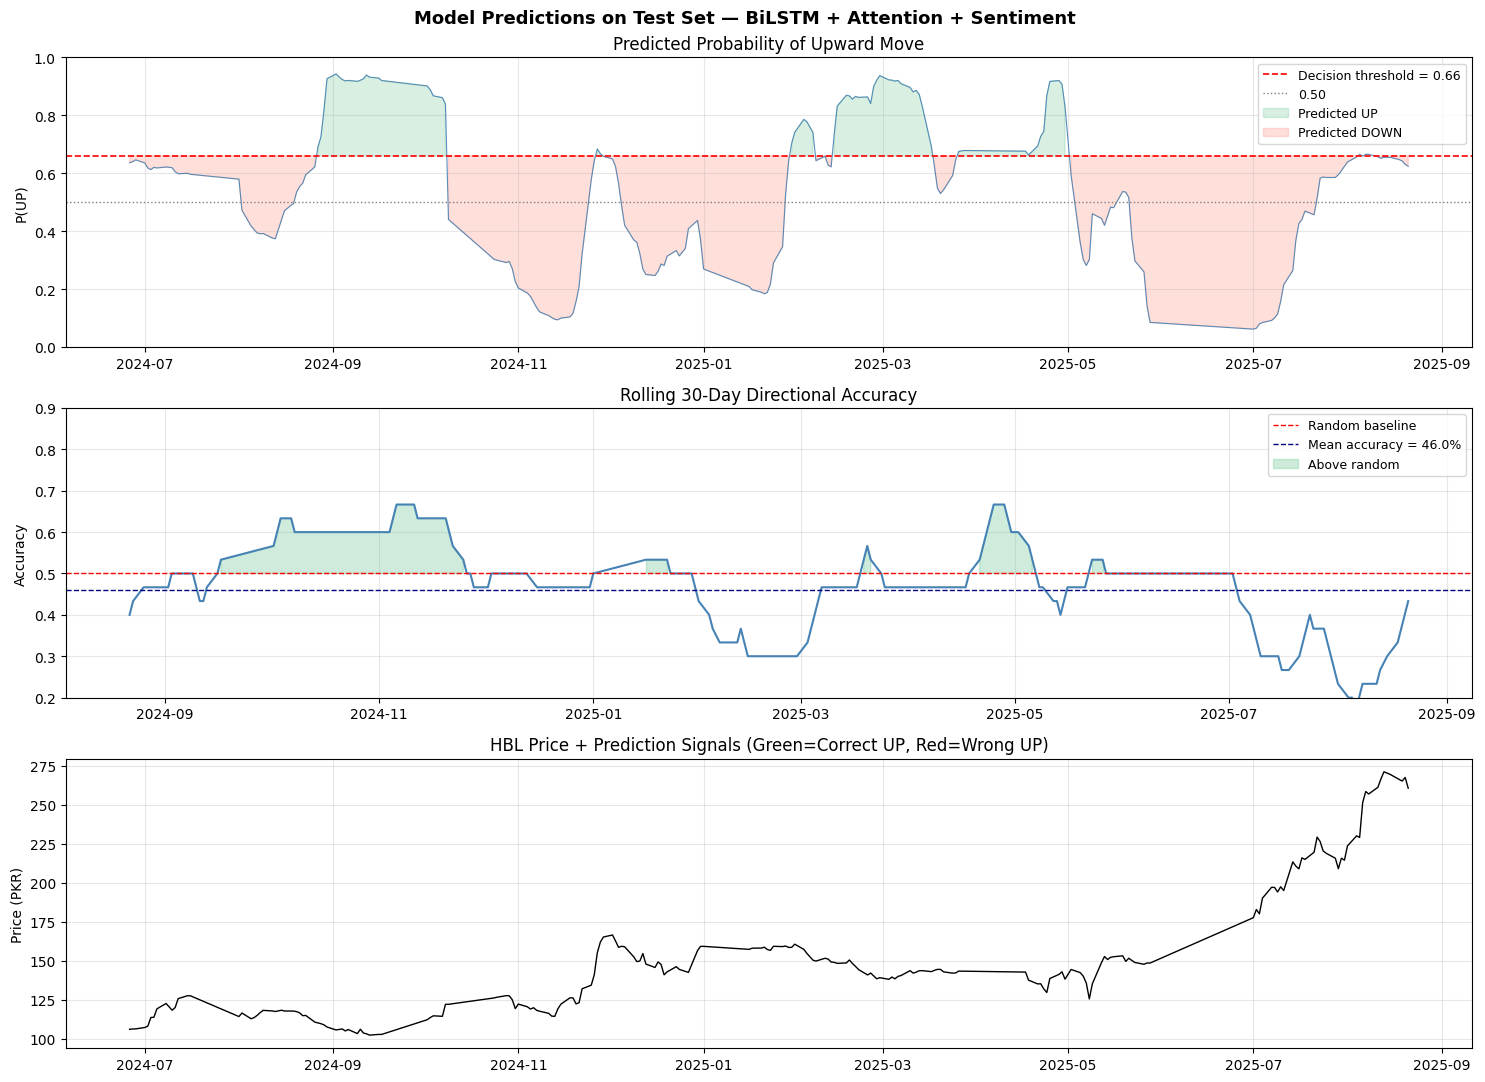

In [16]:
test_dates  = test_df['date'].values[SEQUENCE_LENGTH:]
test_proba  = res_full_opt['proba']
test_preds  = res_full_opt['preds']
test_actual = yf_te

fig, axes = plt.subplots(3, 1, figsize=(15, 11))
fig.suptitle('Model Predictions on Test Set — BiLSTM + Attention + Sentiment',
             fontsize=13, fontweight='bold')

# Plot 1: Predicted probability
ax = axes[0]
ax.plot(test_dates, test_proba, color='steelblue', linewidth=0.8, alpha=0.9)
ax.axhline(best_thresh, color='red', linestyle='--', linewidth=1.2,
           label=f'Decision threshold = {best_thresh:.2f}')
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1, label='0.50')
ax.fill_between(test_dates, best_thresh, test_proba,
                where=(test_proba >= best_thresh),
                alpha=0.2, color='mediumseagreen', label='Predicted UP')
ax.fill_between(test_dates, test_proba, best_thresh,
                where=(test_proba < best_thresh),
                alpha=0.2, color='tomato', label='Predicted DOWN')
ax.set_ylabel('P(UP)')
ax.set_ylim(0, 1)
ax.set_title('Predicted Probability of Upward Move')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Plot 2: Correct vs wrong predictions
ax2 = axes[1]
correct = (test_preds == test_actual)
rolling_acc = pd.Series(correct.astype(float)).rolling(30).mean().values
ax2.plot(test_dates, rolling_acc, color='steelblue', linewidth=1.5)
ax2.axhline(0.5, color='red', linestyle='--', linewidth=1, label='Random baseline')
mean_acc = np.nanmean(rolling_acc)
ax2.axhline(mean_acc, color='navy', linestyle='--', linewidth=1,
            label=f'Mean accuracy = {mean_acc:.1%}')
ax2.fill_between(test_dates, 0.5, rolling_acc,
                 where=(rolling_acc > 0.5), alpha=0.25,
                 color='mediumseagreen', label='Above random')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0.2, 0.9)
ax2.set_title('Rolling 30-Day Directional Accuracy')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Plot 3: HBL stock price + prediction overlay
ax3 = axes[2]
close_test = test_df['Close'].values[SEQUENCE_LENGTH:]
ax3.plot(test_dates, close_test, color='black', linewidth=1, label='HBL Close', zorder=2)

# Mark correct UP predictions in green, wrong in red
for i, (d, prob, actual) in enumerate(zip(test_dates, test_proba, test_actual)):
    pred = int(prob >= best_thresh)
    if pred == 1 and actual == 1:
        ax3.axvspan(d, d, alpha=0.3, color='mediumseagreen', linewidth=0)
    elif pred == 1 and actual == 0:
        ax3.axvspan(d, d, alpha=0.3, color='tomato', linewidth=0)

ax3.set_ylabel('Price (PKR)')
ax3.set_title('HBL Price + Prediction Signals (Green=Correct UP, Red=Wrong UP)')
ax3.grid(True, alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.savefig('predictions_over_time_clf.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 15 — Backtest with Classification Signal

In [17]:
def classification_backtest(proba, actual_returns, close_prices, dates,
                             threshold=0.5, hold_days=5,
                             transaction_cost=0.001, label='Strategy'):
    """
    Non-overlapping 5-day signal backtest.
    Signals are generated every HOLD_DAYS days (no overlap).
    """
    n = len(proba)
    daily_pnl = np.zeros(n)
    signal    = np.zeros(n)
    prev_pos  = 0

    # Step by hold_days to avoid overlapping positions
    for i in range(0, n - hold_days, hold_days):
        p = proba[i]
        if   p >= threshold:       pos = 1   # LONG
        elif p <= (1 - threshold): pos = -1  # SHORT (optional — remove if FYP is long-only)
        else:                      pos = 0   # FLAT

        # Fill hold_days days
        for j in range(i, min(i + hold_days, n)):
            signal[j] = pos
            if j < len(actual_returns):
                daily_pnl[j] = pos * actual_returns[j]

        # Transaction cost on position changes
        if pos != prev_pos:
            daily_pnl[i] -= transaction_cost * abs(pos - prev_pos)
        prev_pos = pos

    # Metrics
    cum_ret    = np.cumprod(1 + daily_pnl) - 1
    log_ret_bh = np.diff(np.log(close_prices + 1e-9), prepend=np.log(close_prices[0]))
    log_ret_bh = log_ret_bh[:n]
    bh_cum     = np.cumprod(1 + log_ret_bh) - 1

    sharpe = daily_pnl.mean() / (daily_pnl.std() + 1e-9) * np.sqrt(252)
    cum_w  = np.cumprod(1 + daily_pnl)
    dd     = (cum_w - np.maximum.accumulate(cum_w)) / np.maximum.accumulate(cum_w)
    max_dd = dd.min()
    active = np.mean(signal != 0)

    print(f'\n═══ {label} Backtest ═══')
    print(f'  Total return  : {cum_ret[-1]:.2%}  (Buy&Hold: {bh_cum[-1]:.2%})')
    print(f'  Sharpe ratio  : {sharpe:.3f}')
    print(f'  Max drawdown  : {max_dd:.2%}')
    print(f'  % Time active : {active:.1%}')

    return {'dates': dates, 'cum_ret': cum_ret, 'bh_cum': bh_cum,
            'signal': signal, 'daily_pnl': daily_pnl, 'dd': dd,
            'sharpe': sharpe, 'max_dd': max_dd, 'active': active,
            'total_ret': cum_ret[-1], 'bh_ret': bh_cum[-1]}


# Daily log returns for the test period
test_daily_ret = test_df['log_return'].values[SEQUENCE_LENGTH:]
test_close     = test_df['Close'].values[SEQUENCE_LENGTH:]

bt = classification_backtest(
    proba          = test_proba,
    actual_returns = test_daily_ret,
    close_prices   = test_close,
    dates          = test_dates,
    threshold      = best_thresh,
    hold_days      = FORWARD_DAYS,
    label          = 'BiLSTM + Sentiment'
)


═══ BiLSTM + Sentiment Backtest ═══
  Total return  : -30.11%  (Buy&Hold: 123.45%)
  Sharpe ratio  : -1.272
  Max drawdown  : -45.48%
  % Time active : 52.3%


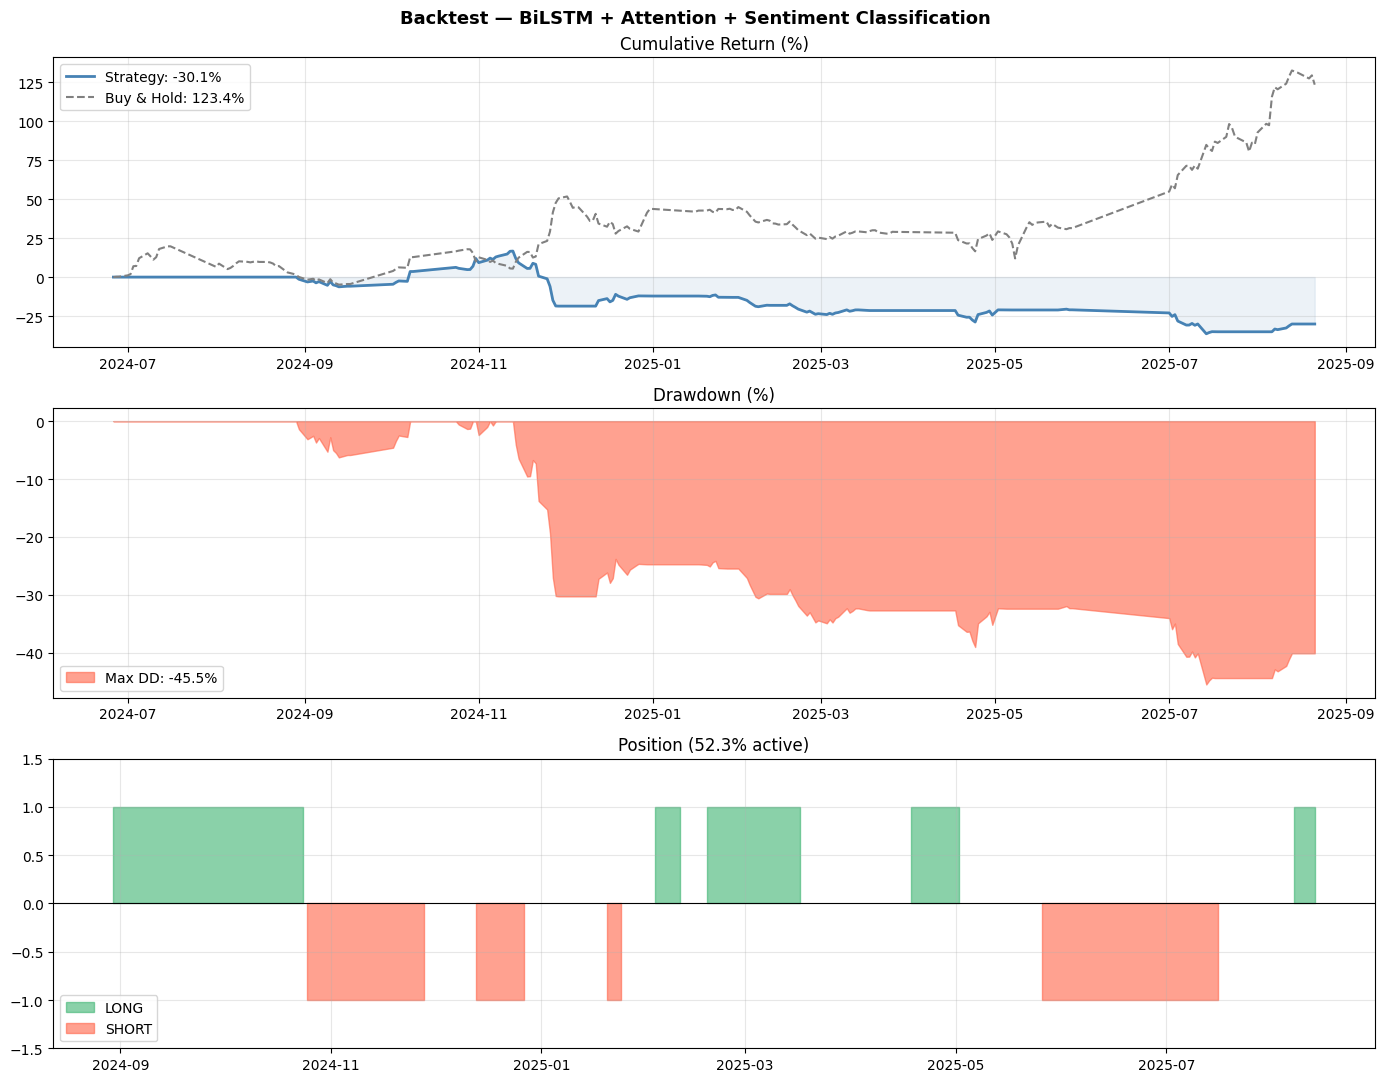

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11))
fig.suptitle('Backtest — BiLSTM + Attention + Sentiment Classification', fontsize=13, fontweight='bold')

# Cumulative return
axes[0].plot(bt['dates'], bt['cum_ret']*100, color='steelblue', linewidth=2,
             label=f"Strategy: {bt['total_ret']:.1%}")
axes[0].plot(bt['dates'], bt['bh_cum']*100, color='gray', linewidth=1.5,
             linestyle='--', label=f"Buy & Hold: {bt['bh_ret']:.1%}")
axes[0].fill_between(bt['dates'], bt['cum_ret']*100, alpha=0.1, color='steelblue')
axes[0].set_title('Cumulative Return (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Drawdown
axes[1].fill_between(bt['dates'], bt['dd']*100, 0, color='tomato', alpha=0.6,
                     label=f"Max DD: {bt['max_dd']:.1%}")
axes[1].set_title('Drawdown (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Position
axes[2].fill_between(bt['dates'], bt['signal'], 0,
                     where=(bt['signal']>0), color='mediumseagreen', alpha=0.6, label='LONG')
axes[2].fill_between(bt['dates'], bt['signal'], 0,
                     where=(bt['signal']<0), color='tomato', alpha=0.6, label='SHORT')
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title(f'Position ({bt["active"]:.1%} active)')
axes[2].set_ylim(-1.5, 1.5)
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.savefig('backtest_clf.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 16 — Final Paper Results Summary

**Copy the output of this cell directly into your paper's Results section.**

In [19]:
print('═' * 65)
print('  FINAL RESULTS — HBL 5-DAY DIRECTION CLASSIFICATION')
print('  BiLSTM + Multi-Head Attention + Sentiment Analysis')
print('═' * 65)

print(f'''
Dataset
  Stock           : HBL (Habib Bank Limited, PSX)
  Period          : {df_clean['date'].min().date()} → {df_clean['date'].max().date()}
  Samples         : {len(df_clean):,}
  Prediction Task : 5-day forward direction (UP / DOWN)
  Sentiment Source: Dawn News (daily + quarterly + annual)

Ablation Study (Test Set)
  {'Model':<42}  {'Acc':>6}  {'F1':>6}  {'AUC':>6}
  {'-'*60}
  {'Majority Class Baseline':<42}  {random_acc:>6.4f}  {random_f1:>6.4f}  {random_auc:>6.4f}
  {'BiLSTM + Attention (Price Only)':<42}  {res_price['accuracy']:>6.4f}  {res_price['f1']:>6.4f}  {res_price['auc']:>6.4f}
  {'BiLSTM + Attention (Price + Sentiment)':<42}  {res_full_opt['accuracy']:>6.4f}  {res_full_opt['f1']:>6.4f}  {res_full_opt['auc']:>6.4f}

Full Model (Price + Sentiment) Detail
  Accuracy         : {res_full_opt['accuracy']:.4f} ({res_full_opt['accuracy']:.2%})
  Weighted F1      : {res_full_opt['f1']:.4f}
  F1 (UP class)    : {res_full_opt['f1_up']:.4f}
  F1 (DOWN class)  : {res_full_opt['f1_down']:.4f}
  AUC-ROC          : {res_full_opt['auc']:.4f}
  Opt. threshold   : {best_thresh:.2f}

Backtest Performance
  Strategy return  : {bt['total_ret']:.2%}
  Buy & Hold       : {bt['bh_ret']:.2%}
  Sharpe ratio     : {bt['sharpe']:.3f}
  Max drawdown     : {bt['max_dd']:.2%}

Sentiment Contribution (vs Price-Only)
  Accuracy uplift  : +{res_full_opt['accuracy'] - res_price['accuracy']:.4f}
  AUC uplift       : +{res_full_opt['auc'] - res_price['auc']:.4f}
''')
print('═' * 65)

═════════════════════════════════════════════════════════════════
  FINAL RESULTS — HBL 5-DAY DIRECTION CLASSIFICATION
  BiLSTM + Multi-Head Attention + Sentiment Analysis
═════════════════════════════════════════════════════════════════

Dataset
  Stock           : HBL (Habib Bank Limited, PSX)
  Period          : 2016-03-09 → 2025-08-21
  Samples         : 1,666
  Prediction Task : 5-day forward direction (UP / DOWN)
  Sentiment Source: Dawn News (daily + quarterly + annual)

Ablation Study (Test Set)
  Model                                          Acc      F1     AUC
  ------------------------------------------------------------
  Majority Class Baseline                     0.4818  0.3133  0.5000
  BiLSTM + Attention (Price Only)             0.4045  0.3910  0.3623
  BiLSTM + Attention (Price + Sentiment)      0.4500  0.4285  0.4048

Full Model (Price + Sentiment) Detail
  Accuracy         : 0.4500 (45.00%)
  Weighted F1      : 0.4285
  F1 (UP class)    : 0.3315
  F1 (DOWN class)  :

## Section 17 — Save Everything

In [20]:
import pickle

# Models already saved by ModelCheckpoint callbacks
# Save comprehensive artifact bundle
artifacts = {
    'feature_scaler_full':  scaler_full,
    'feature_scaler_price': scaler_price,
    'price_features':       PRICE_FEATURES,
    'full_features':        FULL_FEATURES,
    'sentiment_features':   SENTIMENT_FEATURES,
    'seq_len':              SEQUENCE_LENGTH,
    'forward_days':         FORWARD_DAYS,
    'best_threshold':       best_thresh,
    'test_results_full':    {k:v for k,v in res_full_opt.items() if k not in ['proba','preds']},
    'test_results_price':   {k:v for k,v in res_price.items()    if k not in ['proba','preds']},
    'ablation_table':       ablation.to_dict(),
}

with open(SCALER_PATH, 'wb') as f:
    pickle.dump(artifacts, f)

print('✅ All artifacts saved')
print(f'   Full model  : {MODEL_FULL_PATH}')
print(f'   Price model : {MODEL_PRICE_PATH}')
print(f'   Artifacts   : {SCALER_PATH}')
print()
print('To load and run inference on new data:')
print("""
import tensorflow as tf, pickle, numpy as np

with open(SCALER_PATH, 'rb') as f:
    art = pickle.load(f)

model = tf.keras.models.load_model(MODEL_FULL_PATH)

# On new_df with the same feature columns:
X_new = art['feature_scaler_full'].transform(new_df[art['full_features']])
X_seq = X_new[-art['seq_len']:].reshape(1, art['seq_len'], -1)
prob_up = model.predict(X_seq)[0][0]
direction = 'UP' if prob_up >= art['best_threshold'] else 'DOWN'
print(f'Predicted direction: {direction}  (P(UP) = {prob_up:.3f})')
""")

✅ All artifacts saved
   Full model  : C:\Users\Admin\Desktop\Fyp Working\Classification Model\bilstm_clf_full.keras
   Price model : C:\Users\Admin\Desktop\Fyp Working\Classification Model\bilstm_clf_priceonly.keras
   Artifacts   : C:\Users\Admin\Desktop\Fyp Working\Classification Model\scalers.pkl

To load and run inference on new data:

import tensorflow as tf, pickle, numpy as np

with open(SCALER_PATH, 'rb') as f:
    art = pickle.load(f)

model = tf.keras.models.load_model(MODEL_FULL_PATH)

# On new_df with the same feature columns:
X_new = art['feature_scaler_full'].transform(new_df[art['full_features']])
X_seq = X_new[-art['seq_len']:].reshape(1, art['seq_len'], -1)
prob_up = model.predict(X_seq)[0][0]
direction = 'UP' if prob_up >= art['best_threshold'] else 'DOWN'
print(f'Predicted direction: {direction}  (P(UP) = {prob_up:.3f})')

